In [2]:
# Imports

import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

from tensorflow.keras import layers
from tensorflow.keras import Model
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.callbacks import CSVLogger

from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.applications import Xception
from tensorflow.keras.applications import EfficientNetB3

from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg_preprocess
from tensorflow.keras.applications.densenet import preprocess_input as densenet_preprocess
from tensorflow.keras.applications.xception import preprocess_input as xception_preprocess
from tensorflow.keras.applications.efficientnet import preprocess_input as efficientnet_preprocess

2026-06-14 03:15:22.064369: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781406922.253670      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781406922.308231      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781406922.757683      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781406922.757725      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781406922.757728      58 computation_placer.cc:177] computation placer alr

In [3]:
# Configuration

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
NUM_CLASSES = 4
SEED = 42


DATASET_ROOT = "/kaggle/input/datasets/nafeesalmahadi/oct2026-retinal-oct2017-balanced-701515-split/OCT2026"

TRAIN_DIR = os.path.join(DATASET_ROOT, "train_balanced")
VAL_DIR = os.path.join(DATASET_ROOT, "val_balanced")
TEST_DIR = os.path.join(DATASET_ROOT, "test_balanced")

CLASSES = ["CNV", "DME", "DRUSEN", "NORMAL"]

PREPROCESS = {
    "VGG16": vgg_preprocess,
    "ResNet50": resnet_preprocess,
    "DenseNet121": densenet_preprocess,
    "Xception": xception_preprocess,
    "EfficientNetB3": efficientnet_preprocess
}

In [4]:
# GPU check

print(tf.__version__)
print(tf.config.list_physical_devices("GPU"))

2.19.0
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [5]:
# Loading the Dataset

train_ds = tf.keras.utils.image_dataset_from_directory(TRAIN_DIR, image_size=IMG_SIZE, 
                                                       batch_size=BATCH_SIZE, label_mode="int", 
                                                       shuffle=True, seed=SEED)

val_ds = tf.keras.utils.image_dataset_from_directory(VAL_DIR, image_size=IMG_SIZE, batch_size=BATCH_SIZE, 
                                                     label_mode="int", shuffle=False)

test_ds = tf.keras.utils.image_dataset_from_directory(TEST_DIR, image_size=IMG_SIZE, batch_size=BATCH_SIZE, 
                                                      label_mode="int", shuffle=False)

Found 58697 files belonging to 4 classes.


I0000 00:00:1781406984.185471      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Found 12662 files belonging to 4 classes.
Found 12650 files belonging to 4 classes.


In [6]:
# Class Names

class_names = train_ds.class_names
print(class_names)

['CNV', 'DME', 'DRUSEN', 'NORMAL']


In [8]:
# Data Augmentation

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.10),
    layers.RandomContrast(0.10)
])

# Dataset Optimization

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

In [9]:
def build_model(backbone_name, input_shape=(224,224,3), num_classes=4, dropout_rate=0.3):

    backbone_dict = {
        "VGG16": VGG16,
        "ResNet50": ResNet50,
        "DenseNet121": DenseNet121,
        "Xception": Xception,
        "EfficientNetB3": EfficientNetB3
    }

    base_model = backbone_dict[backbone_name](weights="imagenet", include_top=False, input_shape=input_shape)

    base_model.trainable = False

    inputs = layers.Input(shape=input_shape)

    x = data_augmentation(inputs)
    x = x = PREPROCESS[backbone_name](x)
    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(dropout_rate)(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(dropout_rate)(x)
    
    outputs = layers.Dense(num_classes, activation="softmax")(x)
    model = Model(inputs, outputs)

    return model, base_model

In [10]:
# Baseline Training

def train_head(model, train_ds, val_ds, model_name):

    model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                  loss="sparse_categorical_crossentropy",
                  metrics=["accuracy"])

    callbacks = [
        EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
        ReduceLROnPlateau(monitor="val_loss", factor=0.2, patience=2),
        # ModelCheckpoint(f"{model_name}_head.keras", monitor="val_accuracy", save_best_only=True),
        # CSVLogger(f"{model_name}_head_log.csv")
    ]

    history = model.fit(train_ds, validation_data=val_ds, epochs=10, callbacks=callbacks)
    return history

In [11]:
# Fine Tuning

def fine_tune_model(model, base_model, train_ds, val_ds, model_name):

    base_model.trainable = True

    for layer in base_model.layers[:-30]:
        layer.trainable = False

    model.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
                  loss="sparse_categorical_crossentropy",
                  metrics=["accuracy"])

    callbacks = [
        EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
        ReduceLROnPlateau(monitor="val_loss", factor=0.2, patience=2),
        # ModelCheckpoint(f"{model_name}_finetuned.keras", monitor="val_accuracy", save_best_only=True),
        # CSVLogger(f"{model_name}_finetuned_log.csv")
    ]

    history = model.fit(train_ds, validation_data=val_ds, epochs=15, callbacks=callbacks)
    return history

In [15]:
os.makedirs("/kaggle/working/plots/training_curves", exist_ok=True)
os.makedirs("/kaggle/working/plots/confusion_matrices", exist_ok=True)
os.makedirs("/kaggle/working/reports", exist_ok=True)

In [12]:
# Training Curves

def plot_training_curves(history, model_name):

    plt.figure(figsize=(12,5))

    plt.subplot(1,2,1)
    plt.plot(history.history["accuracy"], label="Train")
    plt.plot(history.history["val_accuracy"], label="Validation")
    plt.title(f"{model_name} Accuracy")
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(history.history["loss"], label="Train")
    plt.plot(history.history["val_loss"], label="Validation")
    plt.title(f"{model_name} Loss")
    plt.legend()

    plt.tight_layout()
    # plt.savefig(f"/kaggle/working/plots/training_curves/{model_name}.png", dpi=600, bbox_inches="tight")
    plt.show()
    plt.close()

In [13]:
# Predictions

def get_predictions(model, dataset):
    y_true = np.concatenate([y.numpy() for x, y in dataset])
    y_prob = model.predict(dataset, verbose=1)
    y_pred = np.argmax(y_prob, axis=1)
    return y_true, y_pred, y_prob

In [14]:
# Classification Report

def generate_error_report(model, dataset, class_names, model_name):
    y_true, y_pred, y_prob = get_predictions(model, dataset)
    report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
    report_df = pd.DataFrame(report).transpose()
    # report_df.to_csv(f"/kaggle/working/reports/{model_name}.csv")
    return report_df

In [15]:
# Confusion Matrix

def plot_confusion_matrix(model, dataset, class_names, model_name):
    y_true, y_pred, _ = get_predictions(model, dataset)
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"{model_name} Confusion Matrix")
    plt.tight_layout()
    # plt.savefig(f"/kaggle/working/plots/confusion_matrices/{model_name}.png", dpi=600, bbox_inches="tight")
    plt.show()
    plt.close()

In [16]:
# Infernece Speed

def benchmark_model(model, dataset, n_batches=20):
    times = []

    for i, (x, y) in enumerate(dataset.take(n_batches)):
        start = time.time()
        _ = model.predict(x, verbose=0)
        end = time.time()
        times.append((end - start) / len(x))
        
    return np.mean(times) * 1000

### **VGG -16**

In [17]:
vgg16_model, vgg16_base = build_model("VGG16")

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


#### Baseline Training

In [18]:
vgg16_head_history = train_head(vgg16_model, train_ds, val_ds, "VGG16")

Epoch 1/10


I0000 00:00:1781407047.653342     133 cuda_dnn.cc:529] Loaded cuDNN version 91002


1835/1835 ━━━━━━━━━━━━━━━━━━━━ 168s 87ms/step - accuracy: 0.7580 - loss: 0.6823 - val_accuracy: 0.8281 - val_loss: 0.4567 - learning_rate: 0.0010
Epoch 2/10
1835/1835 ━━━━━━━━━━━━━━━━━━━━ 150s 82ms/step - accuracy: 0.7982 - loss: 0.5524 - val_accuracy: 0.8439 - val_loss: 0.4235 - learning_rate: 0.0010
Epoch 3/10
1835/1835 ━━━━━━━━━━━━━━━━━━━━ 150s 81ms/step - accuracy: 0.8042 - loss: 0.5312 - val_accuracy: 0.8414 - val_loss: 0.4154 - learning_rate: 0.0010
Epoch 4/10
1835/1835 ━━━━━━━━━━━━━━━━━━━━ 150s 82ms/step - accuracy: 0.8089 - loss: 0.5216 - val_accuracy: 0.8493 - val_loss: 0.3935 - learning_rate: 0.0010
Epoch 5/10
1835/1835 ━━━━━━━━━━━━━━━━━━━━ 150s 82ms/step - accuracy: 0.8127 - loss: 0.5147 - val_accuracy: 0.8524 - val_loss: 0.4058 - learning_rate: 0.0010
Epoch 6/10
1835/1835 ━━━━━━━━━━━━━━━━━━━━ 150s 82ms/step - accuracy: 0.8154 - loss: 0.5072 - val_accuracy: 0.8623 - val_loss: 0.3781 - learning_rate: 0.0010
Epoch 7/10
1835/1835 ━━━━━━━━━━━━━━━━━━━━ 150s 82ms/step - accuracy: 

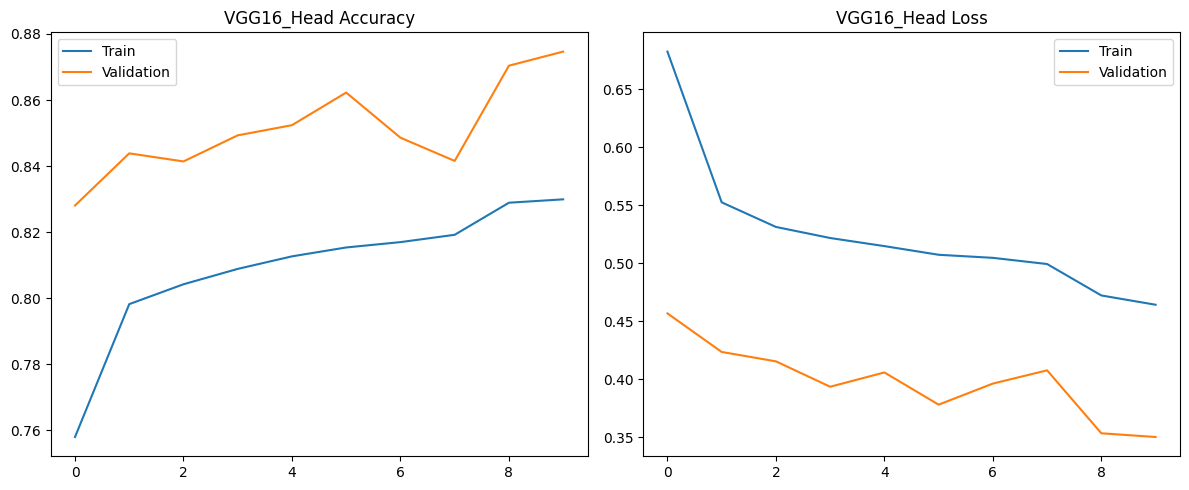

In [19]:
plot_training_curves(vgg16_head_history, "VGG16_Head")

In [20]:
vgg16_head_report = generate_error_report(vgg16_model, test_ds, class_names, "VGG16_Head")
print(vgg16_head_report)

396/396 ━━━━━━━━━━━━━━━━━━━━ 26s 65ms/step
              precision    recall  f1-score       support
CNV            0.899070  0.947275  0.922543   5614.000000
DME            0.886544  0.775087  0.827077   1734.000000
DRUSEN         0.794910  0.401968  0.533937   1321.000000
NORMAL         0.854977  0.977393  0.912096   3981.000000
accuracy       0.876206  0.876206  0.876206      0.876206
macro avg      0.858875  0.775430  0.798913  12650.000000
weighted avg   0.872600  0.876206  0.865588  12650.000000


396/396 ━━━━━━━━━━━━━━━━━━━━ 25s 62ms/step


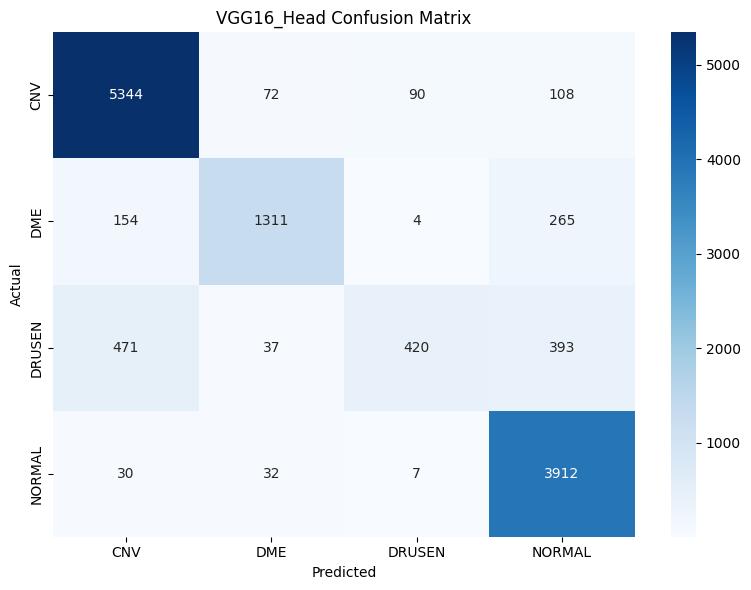

In [29]:
plot_confusion_matrix(vgg16_model, test_ds, class_names, "VGG16_Head")

#### Fine-Tuning

In [21]:
vgg16_ft_history = fine_tune_model(vgg16_model, vgg16_base, train_ds, val_ds, "VGG16")

Epoch 1/15
1835/1835 ━━━━━━━━━━━━━━━━━━━━ 425s 227ms/step - accuracy: 0.9245 - loss: 0.2285 - val_accuracy: 0.9364 - val_loss: 0.1947 - learning_rate: 1.0000e-05
Epoch 2/15
1835/1835 ━━━━━━━━━━━━━━━━━━━━ 416s 227ms/step - accuracy: 0.9492 - loss: 0.1548 - val_accuracy: 0.9480 - val_loss: 0.1693 - learning_rate: 1.0000e-05
Epoch 3/15
1835/1835 ━━━━━━━━━━━━━━━━━━━━ 416s 227ms/step - accuracy: 0.9572 - loss: 0.1297 - val_accuracy: 0.9588 - val_loss: 0.1242 - learning_rate: 1.0000e-05
Epoch 4/15
1835/1835 ━━━━━━━━━━━━━━━━━━━━ 416s 227ms/step - accuracy: 0.9610 - loss: 0.1164 - val_accuracy: 0.9594 - val_loss: 0.1200 - learning_rate: 1.0000e-05
Epoch 5/15
1835/1835 ━━━━━━━━━━━━━━━━━━━━ 416s 227ms/step - accuracy: 0.9657 - loss: 0.1055 - val_accuracy: 0.9586 - val_loss: 0.1273 - learning_rate: 1.0000e-05
Epoch 6/15
1835/1835 ━━━━━━━━━━━━━━━━━━━━ 418s 228ms/step - accuracy: 0.9670 - loss: 0.0956 - val_accuracy: 0.9580 - val_loss: 0.1238 - learning_rate: 1.0000e-05
Epoch 7/15
1835/1835 ━━━━━━━

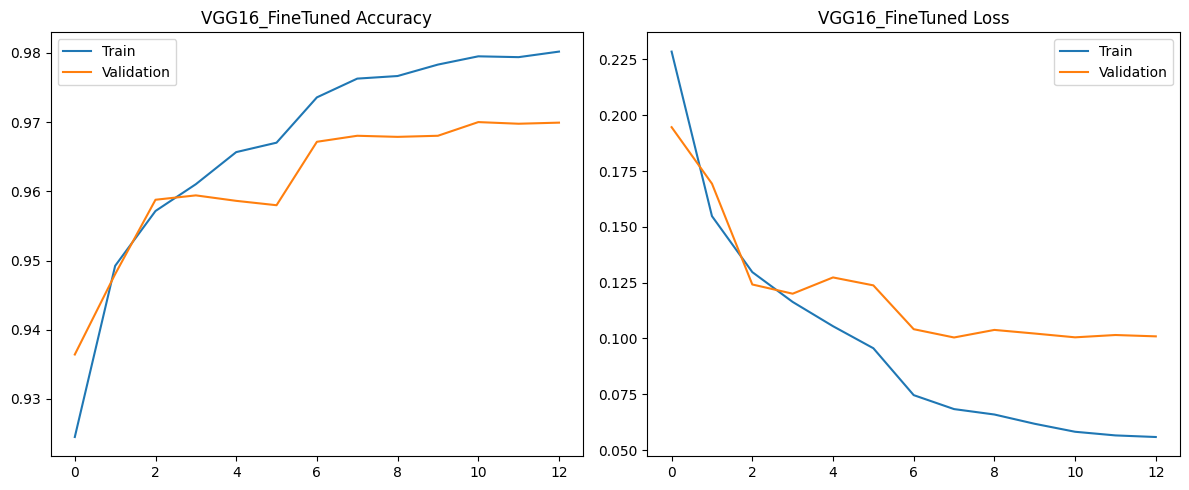

In [22]:
plot_training_curves(vgg16_ft_history, "VGG16_FineTuned")

In [32]:
vgg16_ft_report = generate_error_report(vgg16_model, test_ds, class_names, "VGG16_FineTuned")
print(vgg16_ft_report)

396/396 ━━━━━━━━━━━━━━━━━━━━ 25s 63ms/step
              precision    recall  f1-score       support
CNV            0.981455  0.980406  0.980930   5614.000000
DME            0.974072  0.953287  0.963567   1734.000000
DRUSEN         0.914634  0.908403  0.911508   1321.000000
NORMAL         0.975948  0.988696  0.982281   3981.000000
accuracy       0.971779  0.971779  0.971779      0.971779
macro avg      0.961527  0.957698  0.959572  12650.000000
weighted avg   0.971732  0.971779  0.971726  12650.000000


396/396 ━━━━━━━━━━━━━━━━━━━━ 25s 63ms/step


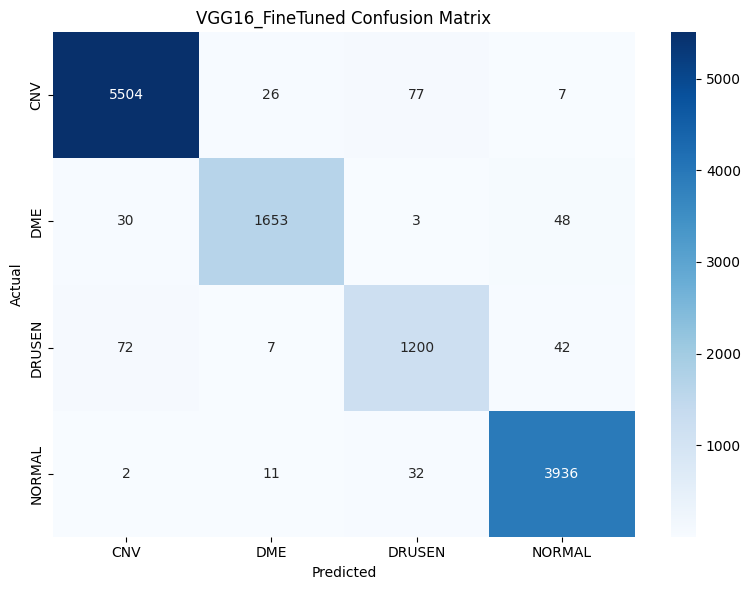

In [33]:
plot_confusion_matrix(vgg16_model, test_ds, class_names, "VGG16_FineTuned")

In [23]:
vgg16_model.save('VGG16_FineTuned.keras')

In [24]:
vgg16_model.save('VGG16_FineTuned.h5')

In [25]:
vgg16_base.save('VGG16_Backbone.keras')

### **RestNet50**

In [40]:
resnet50_model, resnet50_base = build_model("ResNet50")

#### Baseline Training

In [41]:
resnet50_head_history = train_head(resnet50_model, train_ds, val_ds, "ResNet50")

Epoch 1/10
1835/1835 ━━━━━━━━━━━━━━━━━━━━ 181s 94ms/step - accuracy: 0.7897 - loss: 0.5725 - val_accuracy: 0.8191 - val_loss: 0.4736 - learning_rate: 0.0010
Epoch 2/10
1835/1835 ━━━━━━━━━━━━━━━━━━━━ 170s 93ms/step - accuracy: 0.8205 - loss: 0.4919 - val_accuracy: 0.8174 - val_loss: 0.4845 - learning_rate: 0.0010
Epoch 3/10
1835/1835 ━━━━━━━━━━━━━━━━━━━━ 170s 93ms/step - accuracy: 0.8262 - loss: 0.4734 - val_accuracy: 0.8285 - val_loss: 0.4612 - learning_rate: 0.0010
Epoch 4/10
1835/1835 ━━━━━━━━━━━━━━━━━━━━ 170s 93ms/step - accuracy: 0.8296 - loss: 0.4643 - val_accuracy: 0.8407 - val_loss: 0.4358 - learning_rate: 0.0010
Epoch 5/10
1835/1835 ━━━━━━━━━━━━━━━━━━━━ 169s 92ms/step - accuracy: 0.8347 - loss: 0.4519 - val_accuracy: 0.8405 - val_loss: 0.4437 - learning_rate: 0.0010
Epoch 6/10
1835/1835 ━━━━━━━━━━━━━━━━━━━━ 170s 92ms/step - accuracy: 0.8352 - loss: 0.4477 - val_accuracy: 0.8404 - val_loss: 0.4367 - learning_rate: 0.0010
Epoch 7/10
1835/1835 ━━━━━━━━━━━━━━━━━━━━ 170s 93ms/step -

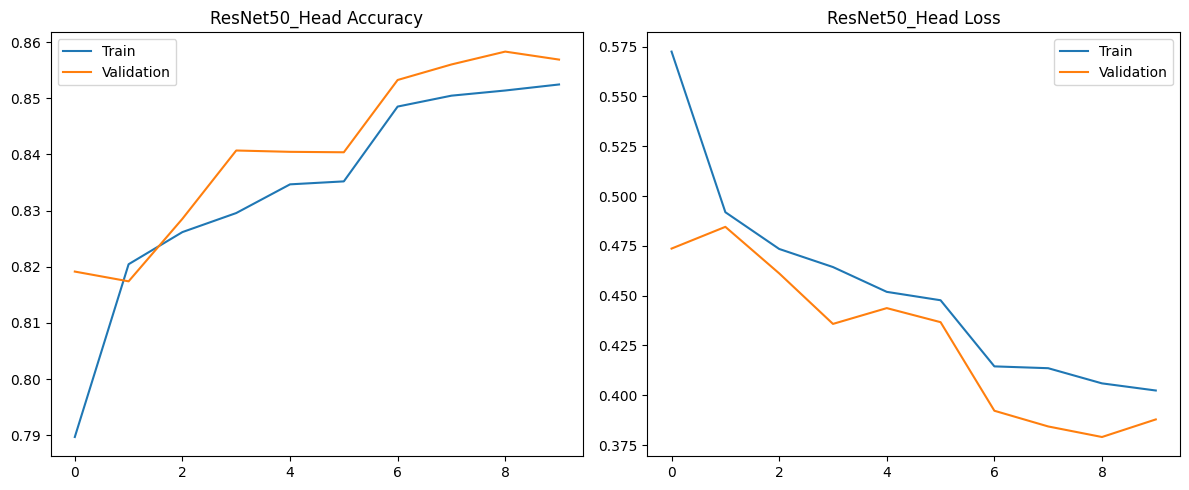

In [42]:
plot_training_curves(resnet50_head_history, "ResNet50_Head")

In [43]:
resnet50_head_report = generate_error_report(resnet50_model, test_ds, class_names, "ResNet50_Head")
print(resnet50_head_report)

396/396 ━━━━━━━━━━━━━━━━━━━━ 32s 75ms/step
              precision    recall  f1-score       support
CNV            0.877801  0.969897  0.921554   5614.000000
DME            0.950833  0.658016  0.777778   1734.000000
DRUSEN         0.808511  0.316427  0.454842   1321.000000
NORMAL         0.830233  0.986436  0.901619   3981.000000
accuracy       0.864111  0.864111  0.864111      0.864111
macro avg      0.866844  0.732694  0.763948  12650.000000
weighted avg   0.865606  0.864111  0.846835  12650.000000


396/396 ━━━━━━━━━━━━━━━━━━━━ 28s 71ms/step


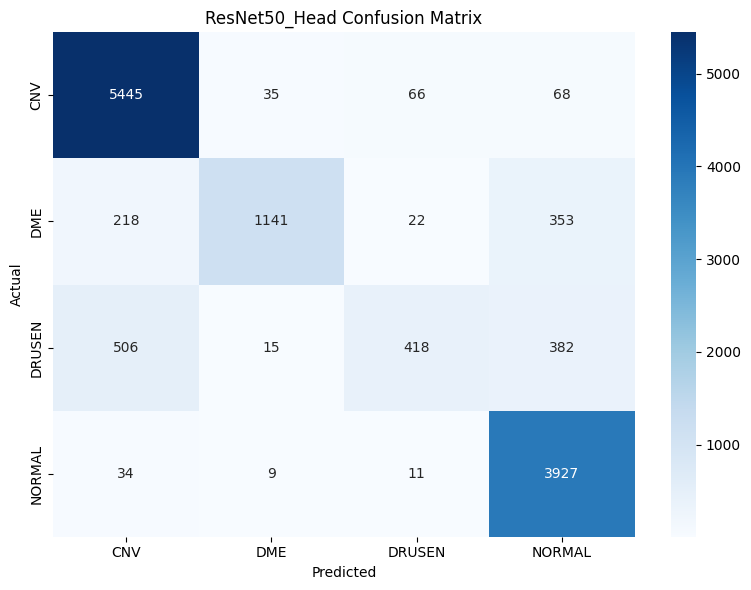

In [44]:
plot_confusion_matrix(resnet50_model, test_ds, class_names, "ResNet50_Head")

#### Fine-Tuning

In [45]:
resnet50_ft_history = fine_tune_model(resnet50_model, resnet50_base, train_ds, val_ds, "ResNet50")

Epoch 1/15
1835/1835 ━━━━━━━━━━━━━━━━━━━━ 234s 120ms/step - accuracy: 0.8769 - loss: 0.3567 - val_accuracy: 0.9070 - val_loss: 0.2770 - learning_rate: 1.0000e-05
Epoch 2/15
1835/1835 ━━━━━━━━━━━━━━━━━━━━ 220s 120ms/step - accuracy: 0.9116 - loss: 0.2559 - val_accuracy: 0.9203 - val_loss: 0.2367 - learning_rate: 1.0000e-05
Epoch 3/15
1835/1835 ━━━━━━━━━━━━━━━━━━━━ 220s 120ms/step - accuracy: 0.9260 - loss: 0.2170 - val_accuracy: 0.9235 - val_loss: 0.2259 - learning_rate: 1.0000e-05
Epoch 4/15
1835/1835 ━━━━━━━━━━━━━━━━━━━━ 219s 119ms/step - accuracy: 0.9329 - loss: 0.1943 - val_accuracy: 0.9319 - val_loss: 0.1983 - learning_rate: 1.0000e-05
Epoch 5/15
1835/1835 ━━━━━━━━━━━━━━━━━━━━ 261s 119ms/step - accuracy: 0.9404 - loss: 0.1713 - val_accuracy: 0.9315 - val_loss: 0.2086 - learning_rate: 1.0000e-05
Epoch 6/15
1835/1835 ━━━━━━━━━━━━━━━━━━━━ 219s 119ms/step - accuracy: 0.9452 - loss: 0.1583 - val_accuracy: 0.9352 - val_loss: 0.2074 - learning_rate: 1.0000e-05
Epoch 7/15
1835/1835 ━━━━━━━

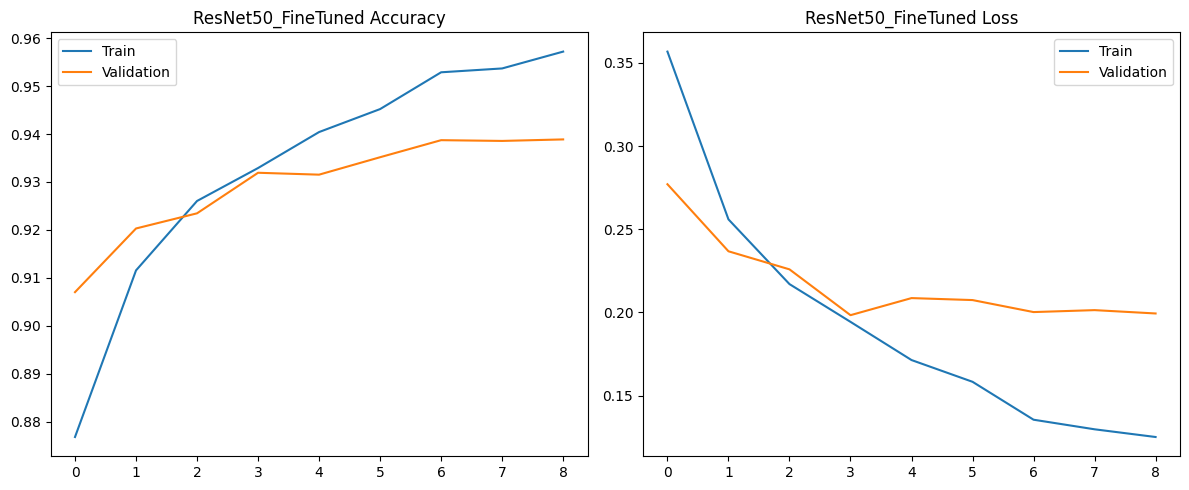

In [46]:
plot_training_curves(resnet50_ft_history, "ResNet50_FineTuned")

In [47]:
resnet50_ft_report = generate_error_report(resnet50_model, test_ds, class_names, "ResNet50_FineTuned")
print(resnet50_ft_report)

396/396 ━━━━━━━━━━━━━━━━━━━━ 32s 76ms/step
              precision    recall  f1-score       support
CNV            0.955633  0.974528  0.964988   5614.000000
DME            0.968648  0.855248  0.908423   1734.000000
DRUSEN         0.884259  0.722937  0.795502   1321.000000
NORMAL         0.913769  0.990203  0.950452   3981.000000
accuracy       0.936838  0.936838  0.936838      0.936838
macro avg      0.930577  0.885729  0.904841  12650.000000
weighted avg   0.936789  0.936838  0.934961  12650.000000


396/396 ━━━━━━━━━━━━━━━━━━━━ 28s 71ms/step


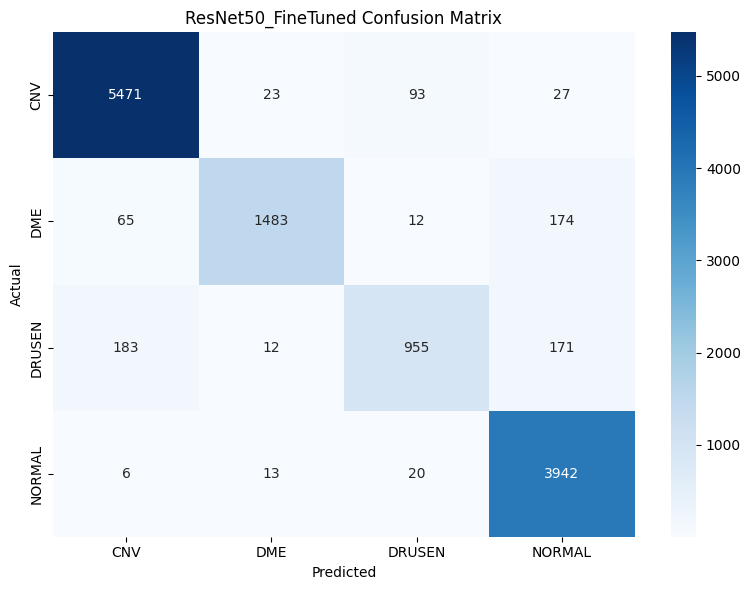

In [48]:
plot_confusion_matrix(resnet50_model, test_ds, class_names, "ResNet50_FineTuned")

### **DenseNet121**

In [49]:
densenet121_model, densenet121_base = build_model("DenseNet121")

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


#### Baseline Training

In [50]:
densenet121_head_history = train_head(densenet121_model, train_ds, val_ds, "DenseNet121")

Epoch 1/10
1835/1835 ━━━━━━━━━━━━━━━━━━━━ 212s 108ms/step - accuracy: 0.7575 - loss: 0.6538 - val_accuracy: 0.8093 - val_loss: 0.4836 - learning_rate: 0.0010
Epoch 2/10
1835/1835 ━━━━━━━━━━━━━━━━━━━━ 191s 104ms/step - accuracy: 0.7801 - loss: 0.5873 - val_accuracy: 0.8395 - val_loss: 0.4345 - learning_rate: 0.0010
Epoch 3/10
1835/1835 ━━━━━━━━━━━━━━━━━━━━ 189s 103ms/step - accuracy: 0.7922 - loss: 0.5640 - val_accuracy: 0.8273 - val_loss: 0.4459 - learning_rate: 0.0010
Epoch 4/10
1835/1835 ━━━━━━━━━━━━━━━━━━━━ 190s 103ms/step - accuracy: 0.7936 - loss: 0.5546 - val_accuracy: 0.8260 - val_loss: 0.4421 - learning_rate: 0.0010
Epoch 5/10
1835/1835 ━━━━━━━━━━━━━━━━━━━━ 191s 104ms/step - accuracy: 0.8077 - loss: 0.5239 - val_accuracy: 0.8562 - val_loss: 0.3960 - learning_rate: 2.0000e-04
Epoch 6/10
1835/1835 ━━━━━━━━━━━━━━━━━━━━ 190s 103ms/step - accuracy: 0.8101 - loss: 0.5140 - val_accuracy: 0.8511 - val_loss: 0.3972 - learning_rate: 2.0000e-04
Epoch 7/10
1835/1835 ━━━━━━━━━━━━━━━━━━━━ 19

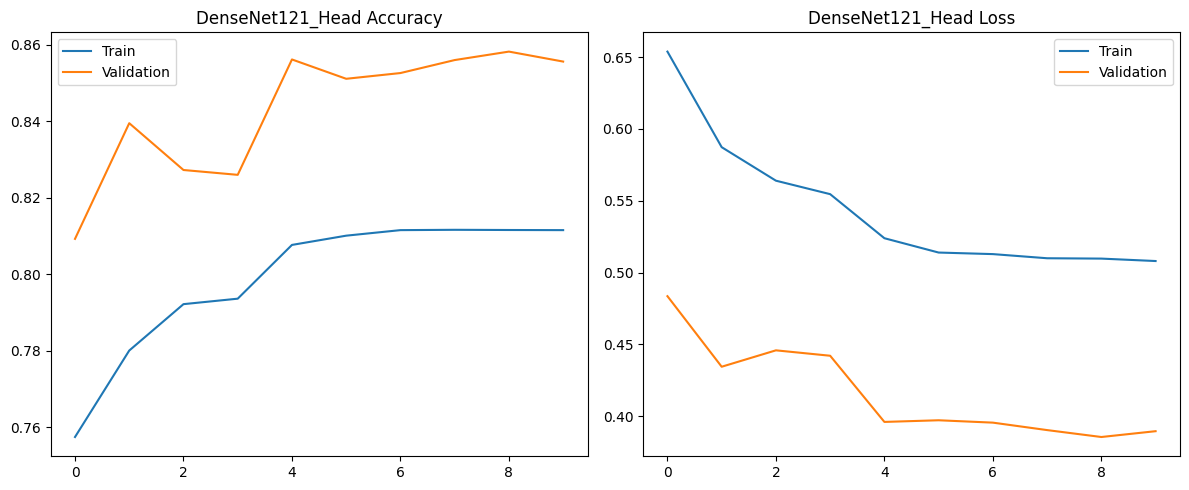

In [51]:
plot_training_curves(densenet121_head_history, "DenseNet121_Head")

In [52]:
densenet121_head_report = generate_error_report(densenet121_model, test_ds, class_names, "DenseNet121_Head")
print(densenet121_head_report)

396/396 ━━━━━━━━━━━━━━━━━━━━ 40s 91ms/step
              precision    recall  f1-score       support
CNV            0.878598  0.951372  0.913538   5614.000000
DME            0.893431  0.705882  0.788660   1734.000000
DRUSEN         0.780220  0.322483  0.456347   1321.000000
NORMAL         0.841246  0.983672  0.906901   3981.000000
accuracy       0.862213  0.862213  0.862213      0.862213
macro avg      0.848374  0.740852  0.766362  12650.000000
weighted avg   0.858603  0.862213  0.846589  12650.000000


396/396 ━━━━━━━━━━━━━━━━━━━━ 32s 80ms/step


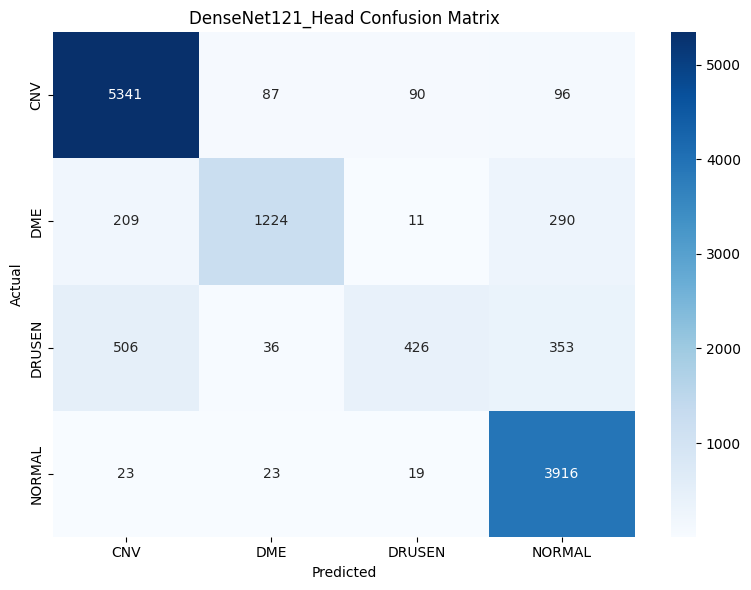

In [53]:
plot_confusion_matrix(densenet121_model, test_ds, class_names, "DenseNet121_Head")

#### Fine Tuning

In [54]:
densenet121_ft_history = fine_tune_model(densenet121_model, densenet121_base, 
                                         train_ds, val_ds, "DenseNet121")

Epoch 1/15
1835/1835 ━━━━━━━━━━━━━━━━━━━━ 226s 114ms/step - accuracy: 0.7811 - loss: 0.6668 - val_accuracy: 0.8559 - val_loss: 0.4016 - learning_rate: 1.0000e-05
Epoch 2/15
1835/1835 ━━━━━━━━━━━━━━━━━━━━ 207s 113ms/step - accuracy: 0.8183 - loss: 0.5052 - val_accuracy: 0.8672 - val_loss: 0.3671 - learning_rate: 1.0000e-05
Epoch 3/15
1835/1835 ━━━━━━━━━━━━━━━━━━━━ 206s 112ms/step - accuracy: 0.8374 - loss: 0.4542 - val_accuracy: 0.8736 - val_loss: 0.3487 - learning_rate: 1.0000e-05
Epoch 4/15
1835/1835 ━━━━━━━━━━━━━━━━━━━━ 205s 112ms/step - accuracy: 0.8500 - loss: 0.4178 - val_accuracy: 0.8817 - val_loss: 0.3329 - learning_rate: 1.0000e-05
Epoch 5/15
1835/1835 ━━━━━━━━━━━━━━━━━━━━ 204s 111ms/step - accuracy: 0.8605 - loss: 0.3916 - val_accuracy: 0.8869 - val_loss: 0.3194 - learning_rate: 1.0000e-05
Epoch 6/15
1835/1835 ━━━━━━━━━━━━━━━━━━━━ 205s 112ms/step - accuracy: 0.8657 - loss: 0.3743 - val_accuracy: 0.8905 - val_loss: 0.3045 - learning_rate: 1.0000e-05
Epoch 7/15
1835/1835 ━━━━━━━

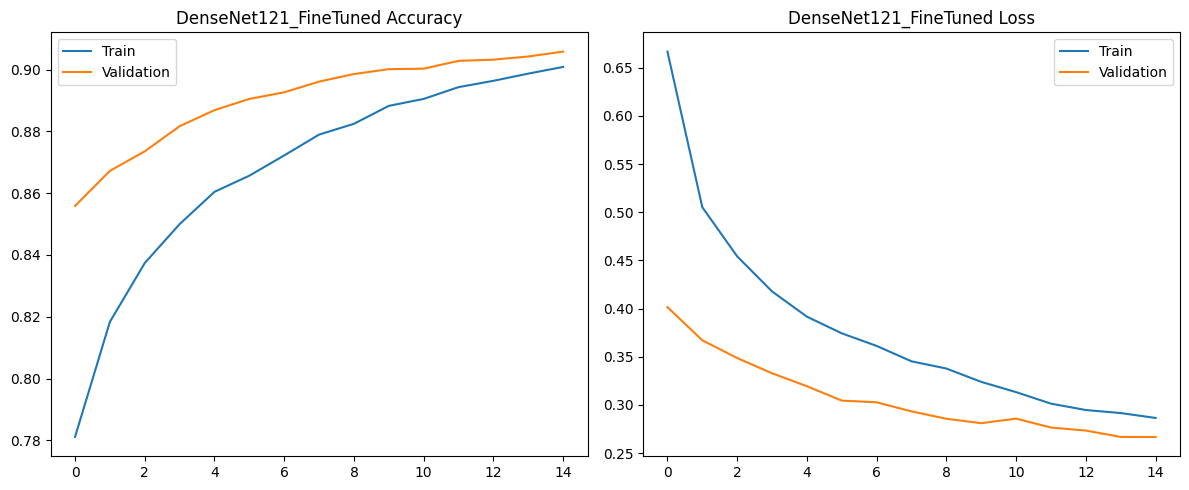

In [55]:
plot_training_curves(densenet121_ft_history, "DenseNet121_FineTuned")

In [56]:
densenet121_ft_report = generate_error_report(densenet121_model, test_ds, 
                                              class_names, "DenseNet121_FineTuned")
print(densenet121_ft_report)

396/396 ━━━━━━━━━━━━━━━━━━━━ 39s 88ms/step
              precision    recall  f1-score       support
CNV            0.939546  0.966156  0.952665   5614.000000
DME            0.956757  0.816609  0.881145   1734.000000
DRUSEN         0.884892  0.558668  0.684919   1321.000000
NORMAL         0.869822  0.996986  0.929073   3981.000000
accuracy       0.912806  0.912806  0.912806      0.912806
macro avg      0.912754  0.834605  0.861951  12650.000000
weighted avg   0.914256  0.912806  0.907477  12650.000000


396/396 ━━━━━━━━━━━━━━━━━━━━ 32s 80ms/step


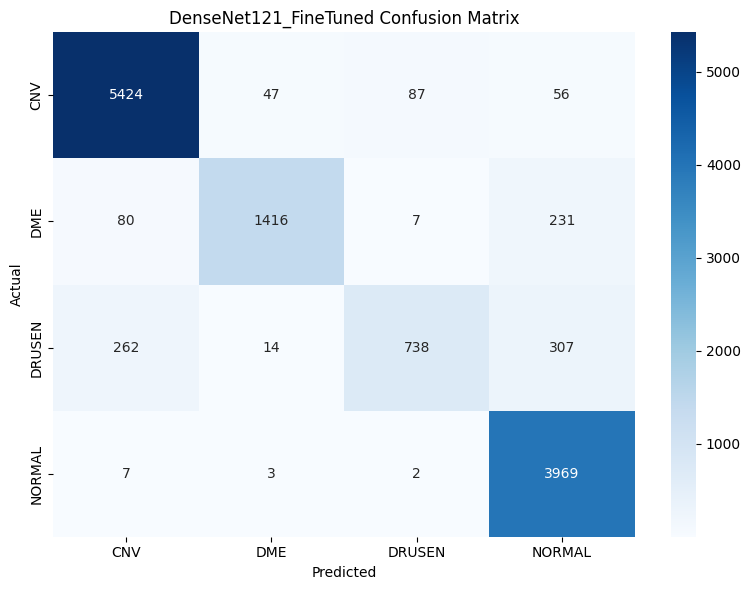

In [57]:
plot_confusion_matrix(densenet121_model, test_ds, class_names, "DenseNet121_FineTuned")

### **Xception**

In [58]:
xception_model, xception_base = build_model("Xception")

83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


#### Baseline Training

In [59]:
xception_head_history = train_head(xception_model, train_ds, val_ds, "Xception")

Epoch 1/10
1835/1835 ━━━━━━━━━━━━━━━━━━━━ 214s 114ms/step - accuracy: 0.7599 - loss: 0.6470 - val_accuracy: 0.8033 - val_loss: 0.5131 - learning_rate: 0.0010
Epoch 2/10
1835/1835 ━━━━━━━━━━━━━━━━━━━━ 206s 112ms/step - accuracy: 0.7848 - loss: 0.5812 - val_accuracy: 0.8007 - val_loss: 0.5175 - learning_rate: 0.0010
Epoch 3/10
1835/1835 ━━━━━━━━━━━━━━━━━━━━ 207s 113ms/step - accuracy: 0.7923 - loss: 0.5593 - val_accuracy: 0.8172 - val_loss: 0.4836 - learning_rate: 0.0010
Epoch 4/10
1835/1835 ━━━━━━━━━━━━━━━━━━━━ 207s 113ms/step - accuracy: 0.7968 - loss: 0.5495 - val_accuracy: 0.8251 - val_loss: 0.4678 - learning_rate: 0.0010
Epoch 5/10
1835/1835 ━━━━━━━━━━━━━━━━━━━━ 207s 113ms/step - accuracy: 0.7981 - loss: 0.5449 - val_accuracy: 0.8303 - val_loss: 0.4536 - learning_rate: 0.0010
Epoch 6/10
1835/1835 ━━━━━━━━━━━━━━━━━━━━ 206s 112ms/step - accuracy: 0.8025 - loss: 0.5366 - val_accuracy: 0.8300 - val_loss: 0.4501 - learning_rate: 0.0010
Epoch 7/10
1835/1835 ━━━━━━━━━━━━━━━━━━━━ 207s 113ms

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


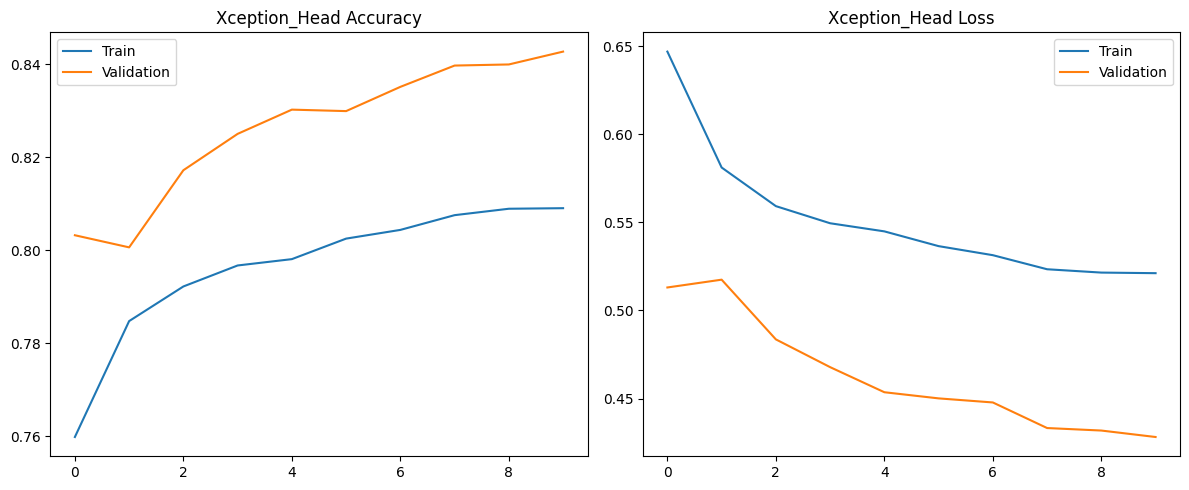

In [60]:
plot_training_curves(xception_head_history, "Xception_Head")

In [61]:
xception_head_report = generate_error_report(xception_model, 
                                             test_ds, class_names, "Xception_Head")
print(xception_head_report)

396/396 ━━━━━━━━━━━━━━━━━━━━ 37s 90ms/step
              precision    recall  f1-score       support
CNV            0.852693  0.955825  0.901319   5614.000000
DME            0.890365  0.618224  0.729748   1734.000000
DRUSEN         0.749550  0.314913  0.443497   1321.000000
NORMAL         0.832753  0.961819  0.892645   3981.000000
accuracy       0.844506  0.844506  0.844506      0.844506
macro avg      0.831340  0.712695  0.741802  12650.000000
weighted avg   0.840811  0.844506  0.827262  12650.000000


396/396 ━━━━━━━━━━━━━━━━━━━━ 35s 87ms/step


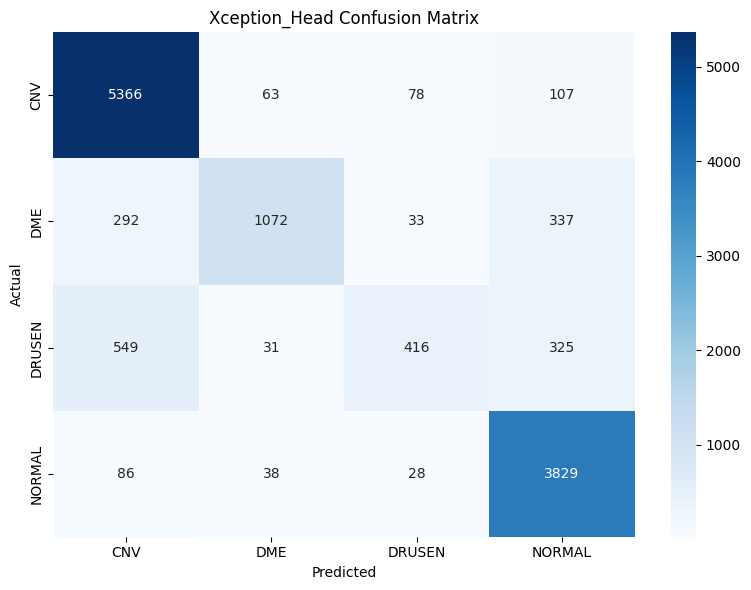

In [62]:
plot_confusion_matrix(xception_model, test_ds, class_names, "Xception_Head")

#### Fine Tuning

In [63]:
xception_ft_history = fine_tune_model(xception_model, xception_base, 
                                      train_ds, val_ds, "Xception")

Epoch 1/15
1835/1835 ━━━━━━━━━━━━━━━━━━━━ 297s 157ms/step - accuracy: 0.8283 - loss: 0.4801 - val_accuracy: 0.8922 - val_loss: 0.3023 - learning_rate: 1.0000e-05
Epoch 2/15
1835/1835 ━━━━━━━━━━━━━━━━━━━━ 287s 157ms/step - accuracy: 0.8886 - loss: 0.3165 - val_accuracy: 0.9084 - val_loss: 0.2593 - learning_rate: 1.0000e-05
Epoch 3/15
1835/1835 ━━━━━━━━━━━━━━━━━━━━ 286s 156ms/step - accuracy: 0.9049 - loss: 0.2710 - val_accuracy: 0.9147 - val_loss: 0.2421 - learning_rate: 1.0000e-05
Epoch 4/15
1835/1835 ━━━━━━━━━━━━━━━━━━━━ 286s 156ms/step - accuracy: 0.9149 - loss: 0.2424 - val_accuracy: 0.9217 - val_loss: 0.2231 - learning_rate: 1.0000e-05
Epoch 5/15
1835/1835 ━━━━━━━━━━━━━━━━━━━━ 287s 156ms/step - accuracy: 0.9227 - loss: 0.2220 - val_accuracy: 0.9264 - val_loss: 0.2102 - learning_rate: 1.0000e-05
Epoch 6/15
1835/1835 ━━━━━━━━━━━━━━━━━━━━ 288s 157ms/step - accuracy: 0.9277 - loss: 0.2075 - val_accuracy: 0.9324 - val_loss: 0.1967 - learning_rate: 1.0000e-05
Epoch 7/15
1835/1835 ━━━━━━━

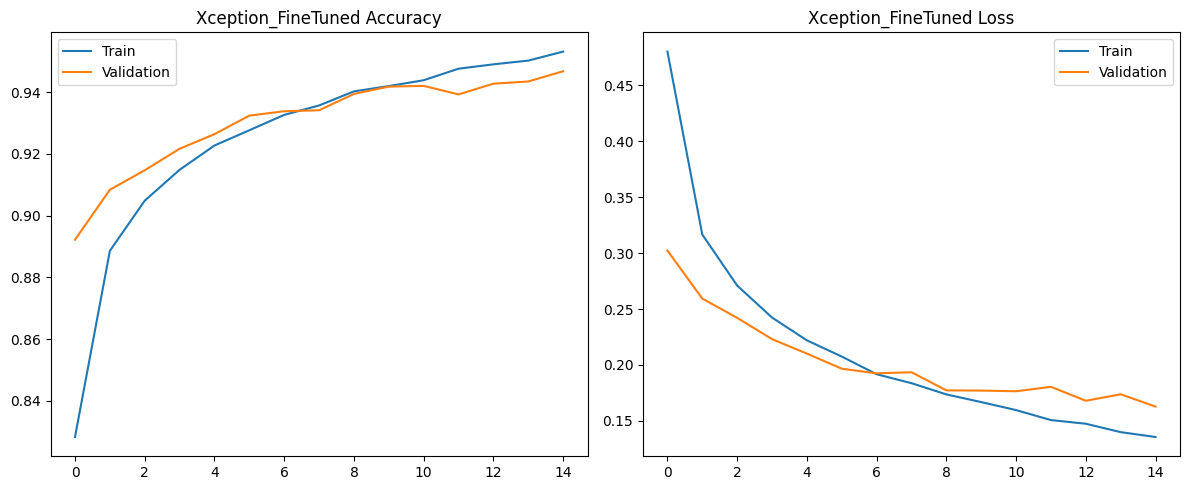

In [64]:
plot_training_curves(xception_ft_history, "Xception_FineTuned")

In [65]:
xception_ft_report = generate_error_report(xception_model, test_ds, 
                                           class_names, "Xception_FineTuned")
print(xception_ft_report)

396/396 ━━━━━━━━━━━━━━━━━━━━ 37s 90ms/step
              precision    recall  f1-score       support
CNV            0.973622  0.959922  0.966723   5614.000000
DME            0.966381  0.911765  0.938279   1734.000000
DRUSEN         0.836907  0.827403  0.832128   1321.000000
NORMAL         0.941289  0.986687  0.963454   3981.000000
accuracy       0.947905  0.947905  0.947905      0.947905
macro avg      0.929550  0.921444  0.925146  12650.000000
weighted avg   0.948178  0.947905  0.947740  12650.000000


396/396 ━━━━━━━━━━━━━━━━━━━━ 35s 88ms/step


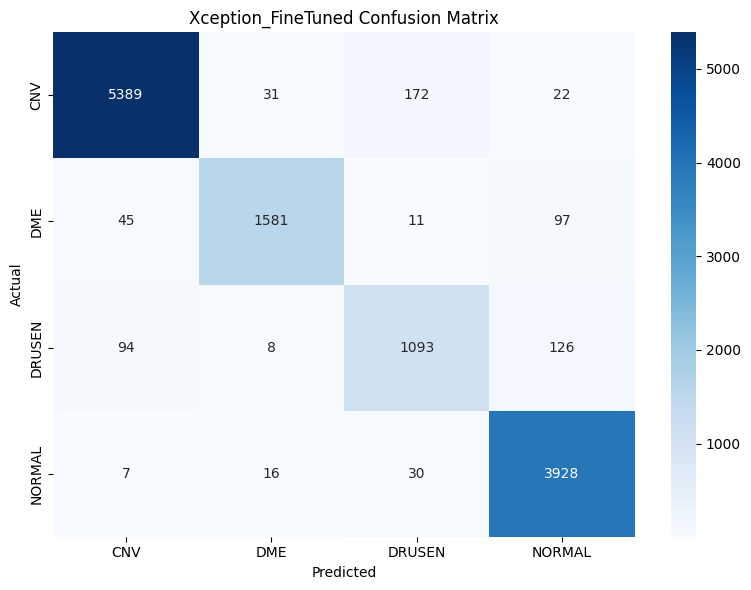

In [66]:
plot_confusion_matrix(xception_model, test_ds, class_names, "Xception_FineTuned")

### **EfficientNetB3**

In [67]:
efficientnetb3_model, efficientnetb3_base = build_model("EfficientNetB3")

43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


#### Baseline Training

In [71]:
efficientnetb3_head_history = train_head(efficientnetb3_model, train_ds, 
                                         val_ds, "EfficientNetB3")

Epoch 1/10


E0000 00:00:1781352056.870152      58 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_7_1/efficientnetb3_1/block1b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


1835/1835 ━━━━━━━━━━━━━━━━━━━━ 213s 108ms/step - accuracy: 0.8120 - loss: 0.5150 - val_accuracy: 0.8619 - val_loss: 0.3699 - learning_rate: 0.0010
Epoch 2/10
1835/1835 ━━━━━━━━━━━━━━━━━━━━ 190s 104ms/step - accuracy: 0.8248 - loss: 0.4791 - val_accuracy: 0.8680 - val_loss: 0.3602 - learning_rate: 0.0010
Epoch 3/10
1835/1835 ━━━━━━━━━━━━━━━━━━━━ 190s 104ms/step - accuracy: 0.8310 - loss: 0.4635 - val_accuracy: 0.8741 - val_loss: 0.3417 - learning_rate: 0.0010
Epoch 4/10
1835/1835 ━━━━━━━━━━━━━━━━━━━━ 189s 103ms/step - accuracy: 0.8347 - loss: 0.4515 - val_accuracy: 0.8716 - val_loss: 0.3437 - learning_rate: 0.0010
Epoch 5/10
1835/1835 ━━━━━━━━━━━━━━━━━━━━ 191s 104ms/step - accuracy: 0.8385 - loss: 0.4431 - val_accuracy: 0.8847 - val_loss: 0.3179 - learning_rate: 0.0010
Epoch 6/10
1835/1835 ━━━━━━━━━━━━━━━━━━━━ 191s 104ms/step - accuracy: 0.8379 - loss: 0.4393 - val_accuracy: 0.8863 - val_loss: 0.3214 - learning_rate: 0.0010
Epoch 7/10
1835/1835 ━━━━━━━━━━━━━━━━━━━━ 190s 103ms/step - acc

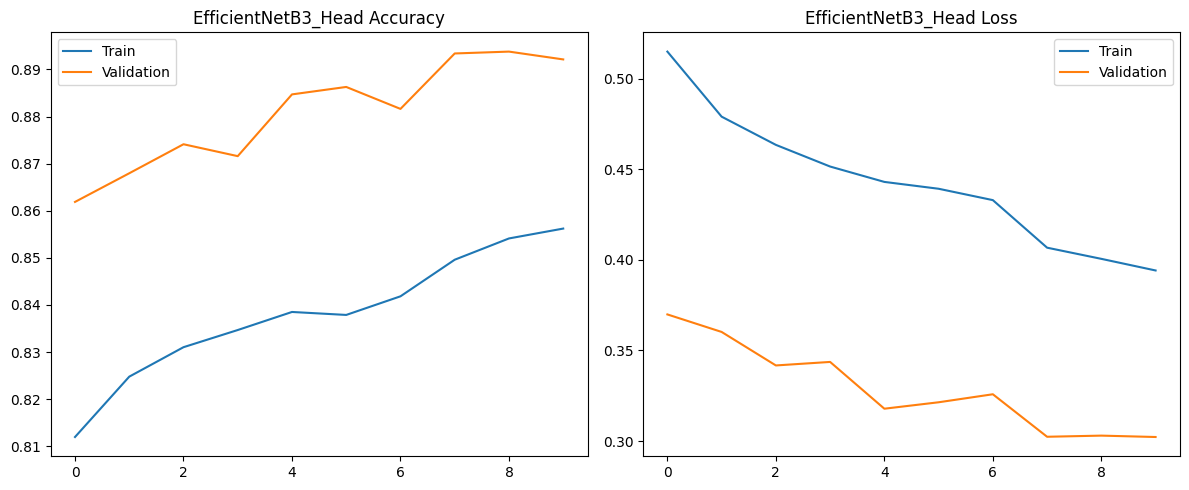

In [72]:
plot_training_curves(efficientnetb3_head_history, "EfficientNetB3_Head")

In [73]:
efficientnetb3_head_report = generate_error_report(efficientnetb3_model, test_ds, 
                                                   class_names, "EfficientNetB3_Head")
print(efficientnetb3_head_report)

396/396 ━━━━━━━━━━━━━━━━━━━━ 40s 94ms/step
              precision    recall  f1-score      support
CNV            0.909229  0.959922  0.933888   5614.00000
DME            0.896850  0.837370  0.866090   1734.00000
DRUSEN         0.736426  0.564724  0.639246   1321.00000
NORMAL         0.923246  0.948757  0.935828   3981.00000
accuracy       0.898340  0.898340  0.898340      0.89834
macro avg      0.866438  0.827693  0.843763  12650.00000
weighted avg   0.893898  0.898340  0.894436  12650.00000


396/396 ━━━━━━━━━━━━━━━━━━━━ 33s 84ms/step


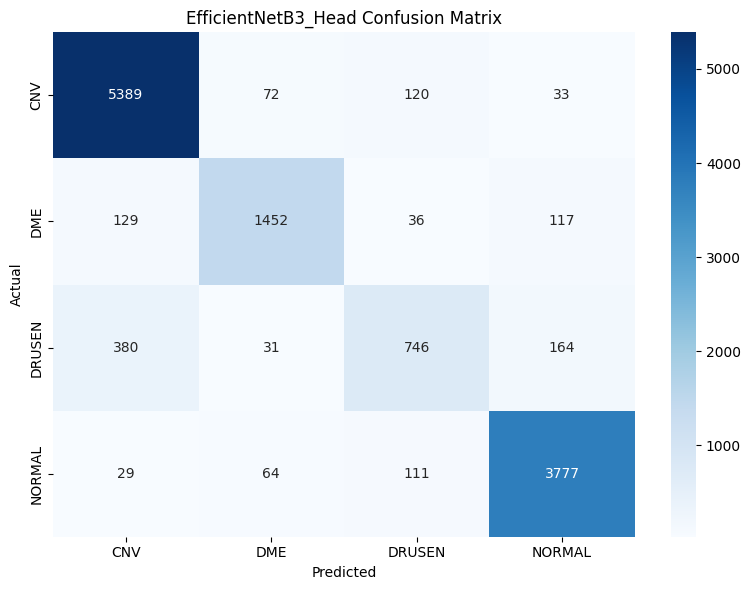

In [74]:
plot_confusion_matrix(efficientnetb3_model, test_ds, class_names, "EfficientNetB3_Head")

#### Fine Tuning

In [75]:
efficientnetb3_ft_history = fine_tune_model(efficientnetb3_model, efficientnetb3_base, 
                                            train_ds, val_ds, "EfficientNetB3")

Epoch 1/15


E0000 00:00:1781354318.432912      58 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_7_1/efficientnetb3_1/block1b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


1835/1835 ━━━━━━━━━━━━━━━━━━━━ 239s 120ms/step - accuracy: 0.8064 - loss: 0.6089 - val_accuracy: 0.8800 - val_loss: 0.3413 - learning_rate: 1.0000e-05
Epoch 2/15
1835/1835 ━━━━━━━━━━━━━━━━━━━━ 216s 118ms/step - accuracy: 0.8479 - loss: 0.4218 - val_accuracy: 0.8942 - val_loss: 0.3031 - learning_rate: 1.0000e-05
Epoch 3/15
1835/1835 ━━━━━━━━━━━━━━━━━━━━ 215s 117ms/step - accuracy: 0.8654 - loss: 0.3715 - val_accuracy: 0.9011 - val_loss: 0.2807 - learning_rate: 1.0000e-05
Epoch 4/15
1835/1835 ━━━━━━━━━━━━━━━━━━━━ 215s 117ms/step - accuracy: 0.8756 - loss: 0.3430 - val_accuracy: 0.9066 - val_loss: 0.2660 - learning_rate: 1.0000e-05
Epoch 5/15
1835/1835 ━━━━━━━━━━━━━━━━━━━━ 216s 118ms/step - accuracy: 0.8839 - loss: 0.3222 - val_accuracy: 0.9110 - val_loss: 0.2540 - learning_rate: 1.0000e-05
Epoch 6/15
1835/1835 ━━━━━━━━━━━━━━━━━━━━ 216s 117ms/step - accuracy: 0.8892 - loss: 0.3091 - val_accuracy: 0.9140 - val_loss: 0.2461 - learning_rate: 1.0000e-05
Epoch 7/15
1835/1835 ━━━━━━━━━━━━━━━━━━

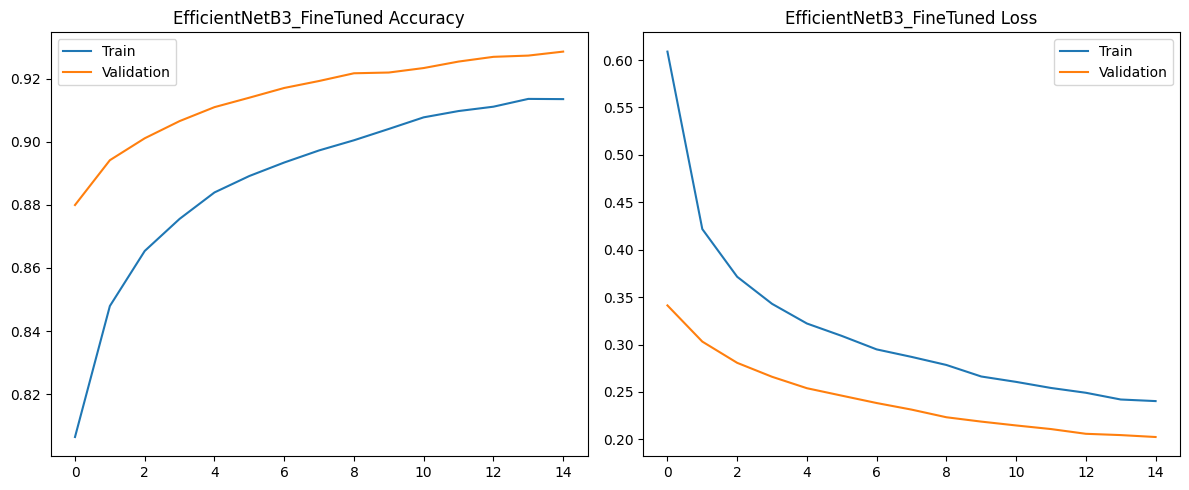

In [76]:
plot_training_curves(efficientnetb3_ft_history, "EfficientNetB3_FineTuned")

In [77]:
efficientnetb3_ft_report = generate_error_report(efficientnetb3_model, test_ds, 
                                                 class_names, "EfficientNetB3_FineTuned")
print(efficientnetb3_ft_report)

396/396 ━━━━━━━━━━━━━━━━━━━━ 40s 92ms/step
              precision    recall  f1-score       support
CNV            0.952154  0.960634  0.956375   5614.000000
DME            0.927859  0.912341  0.920035   1734.000000
DRUSEN         0.849679  0.701741  0.768657   1321.000000
NORMAL         0.934129  0.983170  0.958022   3981.000000
accuracy       0.934071  0.934071  0.934071      0.934071
macro avg      0.915955  0.889472  0.900772  12650.000000
weighted avg   0.932450  0.934071  0.932309  12650.000000


396/396 ━━━━━━━━━━━━━━━━━━━━ 33s 84ms/step


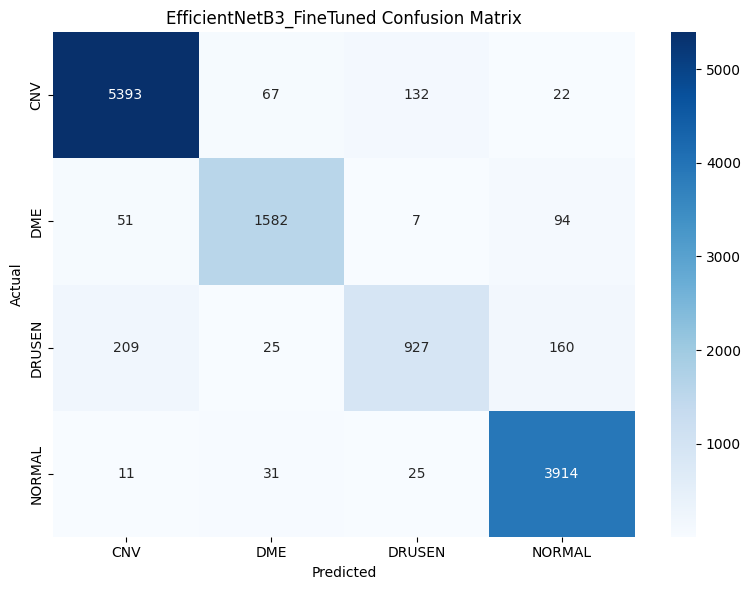

In [78]:
plot_confusion_matrix(efficientnetb3_model, test_ds, class_names, "EfficientNetB3_FineTuned")

In [80]:
# Fina Cmparisn

results_df = pd.DataFrame({
    "Model": [
        "VGG16",
        "ResNet50",
        "DenseNet121",
        "Xception",
        "EfficientNetB3"
    ],
    "Accuracy": [
        vgg16_ft_report.loc["accuracy", "precision"],
        resnet50_ft_report.loc["accuracy", "precision"],
        densenet121_ft_report.loc["accuracy", "precision"],
        xception_ft_report.loc["accuracy", "precision"],
        efficientnetb3_ft_report.loc["accuracy", "precision"]
    ],
    "Macro_F1": [
        vgg16_ft_report.loc["macro avg", "f1-score"],
        resnet50_ft_report.loc["macro avg", "f1-score"],
        densenet121_ft_report.loc["macro avg", "f1-score"],
        xception_ft_report.loc["macro avg", "f1-score"],
        efficientnetb3_ft_report.loc["macro avg", "f1-score"]
    ]
})

results_df.sort_values("Accuracy", ascending=False)
results_df.to_csv('Model-Comparison.csv')